# ExternalGenerationNode As A Mock LLM Policy

In Ax 0.4.3, the relevant import path is:

- `ax.modelbridge.external_generation_node.ExternalGenerationNode`

This notebook uses a mock "LLM" policy:

- it looks at prior trials through Ax state
- it ranks a fixed candidate grid with a hand-written heuristic
- it returns one next candidate at a time

The important point is not the heuristic itself. The point is that Ax still
manages:

- experiment state
- trial indexing
- data attachment
- serialization


In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
from ax.core.data import Data
from ax.core.experiment import Experiment
from ax.core.types import TParameterization
from ax.modelbridge.external_generation_node import ExternalGenerationNode
from ax.modelbridge.generation_strategy import GenerationStrategy
from ax.service.ax_client import AxClient, ObjectiveProperties

warnings.filterwarnings("ignore", message=".*RandomModelBridge does not support prediction.*")

class MockLLMNode(ExternalGenerationNode):
    def __init__(self):
        super().__init__(node_name="mock_llm")
        self.grid = [
            {"x": round(i / 10, 1), "y": round(j / 10, 1)}
            for i in range(11)
            for j in range(11)
        ]

    def update_generator_state(self, experiment: Experiment, data: Data) -> None:
        self._latest_data = data.df.copy()

    def get_next_candidate(self, pending_parameters: list[TParameterization]) -> TParameterization:
        seen = {tuple(sorted(p.items())) for p in pending_parameters}
        if self.experiment is not None:
            for trial in self.experiment.trials.values():
                arm = getattr(trial, "arm", None)
                if arm is not None:
                    seen.add(tuple(sorted(arm.parameters.items())))

        def heuristic_score(p):
            return -abs((p["x"] + p["y"]) - 1.0) - 0.1 * abs(p["x"] - p["y"])

        for candidate in sorted(self.grid, key=heuristic_score, reverse=True):
            key = tuple(sorted(candidate.items()))
            if key not in seen:
                return candidate
        return self.grid[0]

def objective(x: float, y: float) -> dict[str, tuple[float, float]]:
    score = 1.0 - ((x - 0.55) ** 2 + (y - 0.45) ** 2)
    return {"score": (score, 0.0)}

client = AxClient(
    generation_strategy=GenerationStrategy(nodes=[MockLLMNode()]),
    verbose_logging=False,
)
client.create_experiment(
    parameters=[
        {"name": "x", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "y", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
    ],
    objectives={"score": ObjectiveProperties(minimize=False)},
)

rows = []
for _ in range(8):
    params, trial_index = client.get_next_trial()
    result = objective(**params)
    client.complete_trial(trial_index, result)
    rows.append(
        {
            "trial_index": trial_index,
            "x": params["x"],
            "y": params["y"],
            "score": result["score"][0],
        }
    )

df = pd.DataFrame(rows)
df


[WARNING 03-17 12:06:42] ax.service.utils.with_db_settings_base: Ax currently requires a sqlalchemy version below 2.0. This will be addressed in a future release. Disabling SQL storage in Ax for now, if you would like to use SQL storage please install Ax with mysql extras via `pip install ax-platform[mysql]`.
[INFO 03-17 12:06:42] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='x', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='y', parameter_type=FLOAT, range=[0.0, 1.0])], parameter_constraints=[]).


,trial_index,x,y,score
0,0,0.5,0.5,0.995
1,1,0.4,0.6,0.955
2,2,0.6,0.4,0.995
3,3,0.3,0.7,0.875
4,4,0.7,0.3,0.955
5,5,0.2,0.8,0.755
6,6,0.8,0.2,0.875
7,7,0.1,0.9,0.595


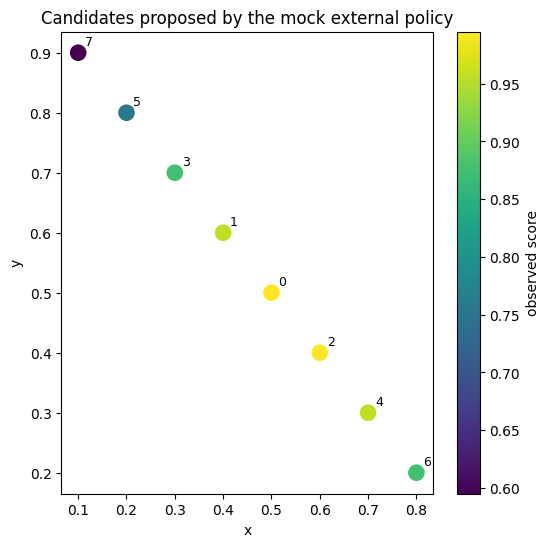

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(df["x"], df["y"], c=df["score"], s=120, cmap="viridis")
for _, row in df.iterrows():
    ax.annotate(
        str(int(row["trial_index"])),
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Candidates proposed by the mock external policy")
plt.colorbar(scatter, ax=ax, label="observed score")
plt.show()


## How This Maps To A Real LLM

In a real integration, the heuristic inside `get_next_candidate(...)` would be replaced with:

1. build a prompt from experiment history and pending points
2. ask the LLM for one next candidate in JSON
3. validate and project the candidate into the search space
4. return that candidate to Ax

Ax would still remain the system of record for trials and observations.
